# Project Assignment: Transfer Learning on Oxford Flowers 102 Dataset

**Objective:** Apply transfer learning using pre-trained CNNs (ResNet50, VGG16, MobileNetV2) to classify images from the Oxford Flowers 102 dataset and compare model performance.

**Dataset:** Oxford Flowers 102 (102 flower categories) from TensorFlow Datasets.

You will:
- Load and explore the dataset
- Preprocess images for each model
- Adapt and train ResNet50, VGG16, and MobileNetV2
- Evaluate on the test split
- Answer reflection questions and attempt optional tasks


tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see this
    [issue](https://github.com/tensorflow/datasets/issues/3022).
    """,
    homepage='https://www.robots.ox.ac.uk/~vgg/data/flowers/102

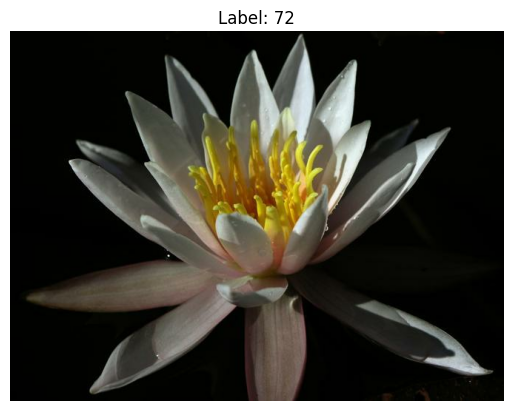

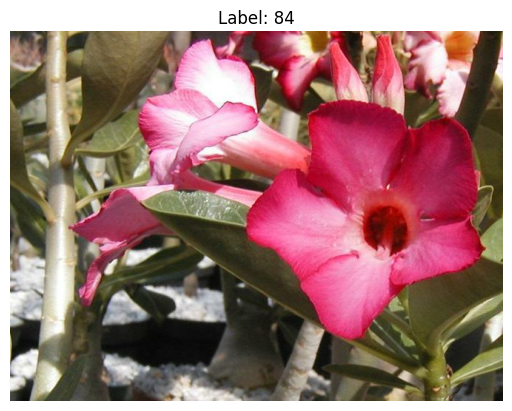

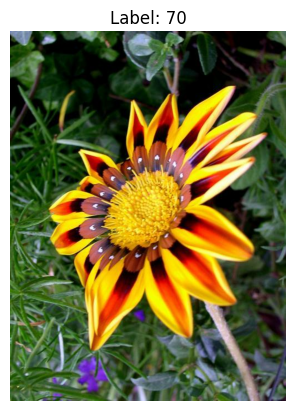

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

# Load Oxford Flowers 102 dataset (train/validation/test provided)
dataset, info = tfds.load('oxford_flowers102:2.1.1', with_info=True, as_supervised=True)
train_ds = dataset['train']
val_ds = dataset['validation']
test_ds = dataset['test']

print(info)
print('Train samples:', info.splits['train'].num_examples)
print('Validation samples:', info.splits['validation'].num_examples)
print('Test samples:', info.splits['test'].num_examples)
print('Number of classes:', info.features['label'].num_classes)

# Visualize a few training examples
for image, label in train_ds.take(3):
    plt.imshow(image)
    plt.title(f'Label: {label.numpy()}')
    plt.axis('off')
    plt.show()


In [2]:
# Data Preprocessing
IMG_SIZE = 224  # 224x224 for ResNet50/VGG16/MobileNetV2
BATCH_SIZE = 32
NUM_CLASSES = 102

# Preprocessing functions per model
from tensorflow.keras.applications import resnet50, vgg16, mobilenet_v2

@tf.function
def preprocess_common(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

train_ds_base = train_ds.map(preprocess_common, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_base = val_ds.map(preprocess_common, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_base = test_ds.map(preprocess_common, num_parallel_calls=tf.data.AUTOTUNE)

train_ds_prep = train_ds_base.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds_prep = val_ds_base.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds_prep = test_ds_base.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [3]:
# Define callbacks used across trainings
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_resnet = ModelCheckpoint('resnet50_best.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
checkpoint_vgg = ModelCheckpoint('vgg16_best.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
checkpoint_mnv2 = ModelCheckpoint('mobilenetv2_best.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

earlystop = EarlyStopping(monitor='val_accuracy', patience=3, mode='max', restore_best_weights=True, verbose=1)


In [4]:
# ResNet50: build, compile, and train
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.models import Model

base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_resnet.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = resnet50.preprocess_input(inputs)
x = base_resnet(x)
x = GlobalAveragePooling2D()(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model_resnet = Model(inputs, outputs)

model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_resnet = model_resnet.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=15,
    callbacks=[checkpoint_resnet, earlystop]
)


Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.0665 - loss: 4.9363
Epoch 1: val_accuracy improved from None to 0.48333, saving model to resnet50_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 718ms/step - accuracy: 0.1510 - loss: 4.2000 - val_accuracy: 0.4833 - val_loss: 2.5798
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.6994 - loss: 1.6938
Epoch 2: val_accuracy improved from 0.48333 to 0.72451, saving model to resnet50_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 690ms/step - accuracy: 0.7235 - loss: 1.5266 - val_accuracy: 0.7245 - val_loss: 1.5023
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9067 - loss: 0.7547
Epoch 3: val_accuracy improved from 0.72451 to 0.80490, saving model to resnet50_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 715ms/step - accuracy: 0.9294 - loss: 0.6756 - val_accuracy: 0.8049 - val_loss: 1.1021
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.9715 - loss: 0.3897
Epoch 4: val_accuracy improve

In [5]:
# VGG16: build, compile, and train
from tensorflow.keras.applications import VGG16

base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_vgg.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = vgg16.preprocess_input(inputs)
x = base_vgg(x)
x = GlobalAveragePooling2D()(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model_vgg = Model(inputs, outputs)

model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_vgg = model_vgg.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=15,
    callbacks=[checkpoint_vgg, earlystop]
)


Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.0214 - loss: 12.0353
Epoch 1: val_accuracy improved from None to 0.06078, saving model to vgg16_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.0304 - loss: 10.1761 - val_accuracy: 0.0608 - val_loss: 7.3198
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.0942 - loss: 6.0699
Epoch 2: val_accuracy improved from 0.06078 to 0.16667, saving model to vgg16_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.1402 - loss: 5.4103 - val_accuracy: 0.1667 - val_loss: 4.7482
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.3052 - loss: 3.3028
Epoch 3: val_accuracy improved from 0.16667 to 0.28235, saving model to vgg16_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.3627 - loss: 2.9601 - val_accuracy: 0.2824 - val_loss: 3.4249
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [6]:
# MobileNetV2: build, compile, and train
from tensorflow.keras.applications import MobileNetV2

base_mnv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_mnv2.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = mobilenet_v2.preprocess_input(inputs)
x = base_mnv2(x)
x = GlobalAveragePooling2D()(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model_mnv2 = Model(inputs, outputs)

model_mnv2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_mnv2 = model_mnv2.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=15,
    callbacks=[checkpoint_mnv2, earlystop]
)


Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.0550 - loss: 4.6840
Epoch 1: val_accuracy improved from None to 0.39412, saving model to mobilenetv2_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 241ms/step - accuracy: 0.1324 - loss: 4.2399 - val_accuracy: 0.3941 - val_loss: 3.0825
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6793 - loss: 2.2579
Epoch 2: val_accuracy improved from 0.39412 to 0.65196, saving model to mobilenetv2_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - accuracy: 0.6922 - loss: 2.0769 - val_accuracy: 0.6520 - val_loss: 1.9947
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8882 - loss: 1.1601
Epoch 3: val_accuracy improved from 0.65196 to 0.73431, saving model to mobilenetv2_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - accuracy: 0.9020 - loss: 1.0938 - val_accuracy: 0.7343 - val_loss: 1.5228
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [7]:
# Evaluate models on the test set
loss_resnet, acc_resnet = model_resnet.evaluate(test_ds_prep)
loss_vgg, acc_vgg = model_vgg.evaluate(test_ds_prep)
loss_mnv2, acc_mnv2 = model_mnv2.evaluate(test_ds_prep)

print(f'ResNet50   - Loss: {loss_resnet:.4f}, Accuracy: {acc_resnet:.4f}')
print(f'VGG16      - Loss: {loss_vgg:.4f}, Accuracy: {acc_vgg:.4f}')
print(f'MobileNetV2- Loss: {loss_mnv2:.4f}, Accuracy: {acc_mnv2:.4f}')


193/193 ━━━━━━━━━━━━━━━━━━━━ 68s 350ms/step - accuracy: 0.8276 - loss: 0.8217
193/193 ━━━━━━━━━━━━━━━━━━━━ 161s 836ms/step - accuracy: 0.0463 - loss: 7.3604
193/193 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.3521 - loss: 3.1902
ResNet50   - Loss: 0.8217, Accuracy: 0.8276
VGG16      - Loss: 7.3604, Accuracy: 0.0463
MobileNetV2- Loss: 3.1902, Accuracy: 0.3521


In [8]:
# Optional: Train on validation split as well (for demonstration)
# Note: Typically we only validate on validation split; training on it is optional/for experiments.
history_resnet_val = model_resnet.fit(val_ds_prep, epochs=3)
history_vgg_val = model_vgg.fit(val_ds_prep, epochs=3)
history_mnv2_val = model_mnv2.fit(val_ds_prep, epochs=3)


Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 357ms/step - accuracy: 0.8294 - loss: 0.7200
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 349ms/step - accuracy: 0.9598 - loss: 0.2749
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 347ms/step - accuracy: 0.9912 - loss: 0.1258
Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 842ms/step - accuracy: 0.0902 - loss: 6.2586
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 843ms/step - accuracy: 0.3137 - loss: 3.2932
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5833 - loss: 1.7571
Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.4922 - loss: 2.6231
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.8137 - loss: 1.4148
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.9392 - loss: 0.8143


In [9]:
# Optional: Fine-tuning top layers
# Unfreeze top layers and fine-tune with a lower learning rate

def unfreeze_and_finetune(model, base_model, layers_to_unfreeze=50, lr=1e-5):
    for layer in base_model.layers[-layers_to_unfreeze:]:
        layer.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Fine-tune ResNet50 (e.g., last 30 layers)
unfreeze_and_finetune(model_resnet, base_resnet, layers_to_unfreeze=30, lr=1e-5)
history_resnet_ft = model_resnet.fit(
    train_ds_prep, validation_data=val_ds_prep, epochs=5, callbacks=[earlystop]
)

# Fine-tune VGG16
unfreeze_and_finetune(model_vgg, base_vgg, layers_to_unfreeze=30, lr=1e-5)
history_vgg_ft = model_vgg.fit(
    train_ds_prep, validation_data=val_ds_prep, epochs=5, callbacks=[earlystop]
)

# Fine-tune MobileNetV2
unfreeze_and_finetune(model_mnv2, base_mnv2, layers_to_unfreeze=30, lr=1e-5)
history_mnv2_ft = model_mnv2.fit(
    train_ds_prep, validation_data=val_ds_prep, epochs=5, callbacks=[earlystop]
)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 877ms/step - accuracy: 0.8794 - loss: 0.4569 - val_accuracy: 0.9990 - val_loss: 0.0441
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 992ms/step - accuracy: 0.9814 - loss: 0.1402 - val_accuracy: 0.9990 - val_loss: 0.0474
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9990 - loss: 0.0718 - val_accuracy: 0.9971 - val_loss: 0.0617
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 1.0000 - loss: 0.0453 - val_accuracy: 0.9961 - val_loss: 0.0816
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 0.5029 - loss: 1.9712 - val_accuracy: 0.7716 - val_loss: 0.9109
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 0.7775 - loss: 0.9000 - val_accuracy: 0.8059 - val_loss: 0.7107
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 0.9010 - loss: 0.3918 - val_accuracy: 0.8216 - val_loss: 0.6560
Epoch 3: early stopping
Restoring